In [ ]:
import joblib

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from loguru import logger

%matplotlib inline

pd.set_option("display.max_columns", None)

In [ ]:
from src.evaluation import build_predictions_report

In [62]:
def plot_barh_by_model(results_df, level, x, y="model", hue=None, title="", figsize=(8, 6)):
    """Barplot horizontal genérico para comparar modelos por una métrica."""
    palette = {"ML": "#1f77b4", "Statistical": "#ff7f0e", "Naive": "#2ca02c"}
    df_sorted = results_df.sort_values(x, ascending=True)
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(df_sorted, x=x, y=y, hue=hue, hue_order=list(palette.keys()), order=df_sorted[y],
                dodge=False, palette=palette if hue else None, ax=ax)
    ax.set_title(f"{level} | {title}", loc="left", pad=20)
    ax.set_xlabel("")
    ax.set_ylabel("")
    sns.despine()
    if hue:
        ax.legend(title=hue, loc="upper right")
    plt.tight_layout()
    plt.show()

In [55]:
!ls ../artifacts/models/

level_01_daily_total_sales_artifact.pkl
level_01_weekly_total_sales_artifact.pkl
level_02_daily_state_sales_artifact.pkl
level_02_weekly_state_sales_artifact.pkl
level_03_daily_cat_sales_artifact.pkl
level_03_weekly_cat_sales_artifact.pkl
level_04_daily_dept_sales_artifact.pkl
level_04_weekly_dept_sales_artifact.pkl
level_05_daily_state_cat_sales_artifact.pkl
level_05_weekly_state_cat_sales_artifact.pkl
level_06_daily_store_sales_artifact.pkl
level_06_weekly_store_sales_artifact.pkl
level_07_daily_state_dept_sales_artifact.pkl
level_07_weekly_state_dept_sales_artifact.pkl
level_08_daily_store_cat_sales_artifact.pkl
level_08_weekly_store_cat_sales_artifact.pkl
level_09_daily_store_dept_sales_artifact.pkl
level_09_weekly_store_dept_sales_artifact.pkl
registry.json
versions


In [65]:
ARTIFACT = "level_09_daily_store_dept_sales_artifact"

In [66]:
import joblib
from src.data.dataset import reconstruct_test_data

artifact_path = f"../artifacts/models/{ARTIFACT}.pkl"
artifact = joblib.load(artifact_path)

grainly = "daily" if "daily" in artifact_path else "weekly"
level = artifact["level"]
model = artifact["model"]
FEATURES = artifact["features"]
feature_importance = artifact["feature_importance"]
results_df = artifact["results_df"]

X_test, y_test, artifact["train"], artifact["test"] = reconstruct_test_data(artifact)

2026-09-17 13:28:48.786 | INFO     | src.data.dataset:load_data:58 - level_09_daily_store_dept | target=sales | 135,870 filas | 191 features (9 categóricas)
2026-09-17 13:28:49.004 | INFO     | src.data.temporal_split:log_summary:41 - Train : 2011-01-29 to 2015-04-26 (1,549 days, 108,430 rows)
2026-09-17 13:28:49.005 | INFO     | src.data.temporal_split:log_summary:42 - Valid : 2015-04-27 to 2016-04-24 (364 days, 25,480 rows)
2026-09-17 13:28:49.007 | INFO     | src.data.temporal_split:log_summary:43 - Test  : 2016-04-25 to 2016-05-22 (28 days, 1,960 rows)
2026-09-17 13:28:49.494 | INFO     | src.data.dataset:split_data:119 - Features: 91 (2 categóricas)


In [67]:
import dataframe_image as dfi

df_sample = X_test.head(8).T

dfi.export(df_sample, 'df_sample.png', table_conversion='matplotlib',max_cols=8, max_rows=25, fontsize=12)
df_sample

,133910,133911,133912,133913,133914,133915,133916,133917
dept_id,HOUSEHOLD_1,HOUSEHOLD_2,HOUSEHOLD_2,FOODS_1,FOODS_1,FOODS_1,FOODS_2,HOBBIES_2
event_name_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
avg_sell_price,3.934923,5.286519,4.477266,3.111562,2.782731,3.523379,3.063094,1.922708
price_lag_7,4.047075,4.579304,4.424472,2.933223,3.591413,2.466736,3.524977,1.64
price_change,-0.027712,0.154437,0.011932,0.0608,-0.225171,0.428357,-0.131032,0.172383
...,...,...,...,...,...,...,...,...
rolling_mean_lag364_window_size28,741.357117,129.892853,130.678574,309.785706,218.75,243.071426,413.107147,27.928572
rolling_std_lag364_window_size91,175.874557,20.585531,31.032778,71.499512,61.118382,55.528461,101.444351,10.58622
rolling_min_lag364_window_size91,457.0,84.0,52.0,170.0,97.0,126.0,186.0,10.0
seasonal_mean_lag364_7_8,707.375,115.25,118.125,261.625,148.0,185.875,396.375,25.0


In [68]:
results_df = results_df.query("model != 'xgboost (final, bench default)'")

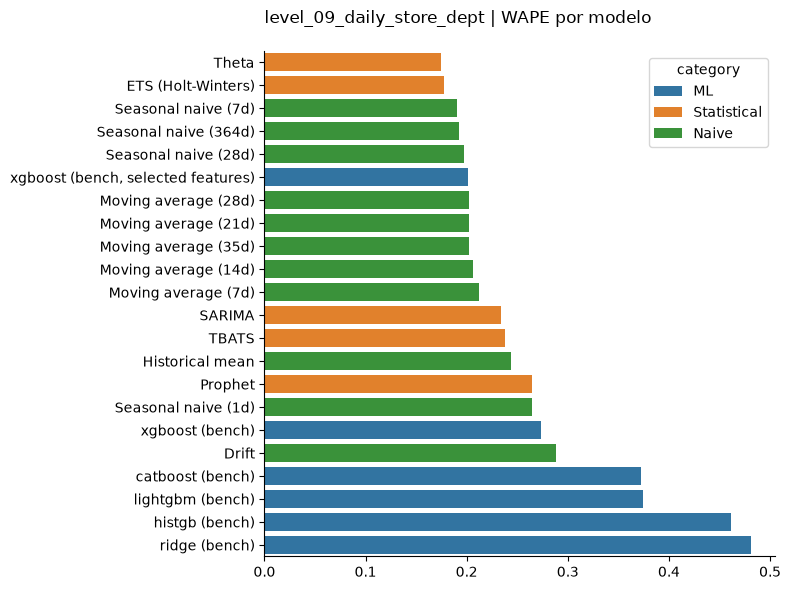

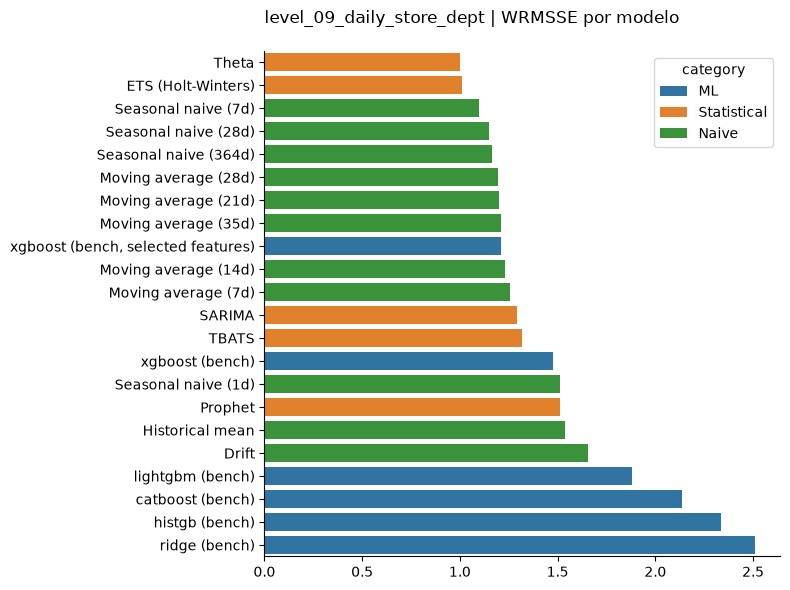

In [69]:
for col in ['wape', 'wrmsse']:
    dict_rename = {
        'wape': 'WAPE',
        'wrmsse': 'WRMSSE'
    }
    plot_barh_by_model(results_df, level, hue="category", x=col, y="model", title=f"{dict_rename[col]} por modelo")

## Explicación modelo

In [70]:
import shap

explainer = artifact["explainer"]

X_shap = model.prepare(X_test.sample(n=min(300_000, len(X_test)), random_state=42))

cat_cols = [c for c in X_shap.columns if isinstance(X_shap[c].dtype, pd.CategoricalDtype)]
if cat_cols:
    X_shap = X_shap.assign(**{c: X_shap[c].cat.codes for c in cat_cols})

shap_values = explainer.shap_values(X_shap)
shap_df = pd.DataFrame(shap_values, columns=X_shap.columns, index=X_shap.index)

importance_df = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)

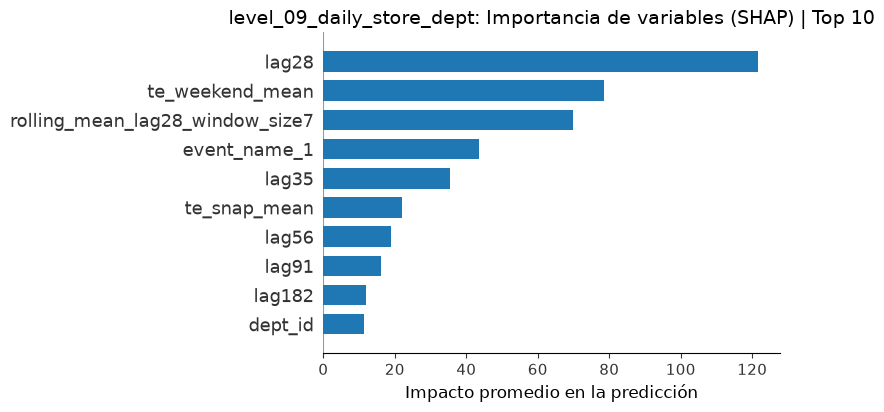

In [71]:
top = 10

shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    max_display=top,
    show=False,
    plot_size=(8, 4),
    color="#1f77b4",
)

plt.title(f"{level}: Importancia de variables (SHAP) | Top {top}", fontsize=14)
plt.xlabel("Impacto promedio en la predicción", fontsize=12)
plt.show()

# Predicciones

In [72]:
from src.evaluation import analizar_prediccion, plot_forecast

In [73]:
metrics_test_final, df_pred = build_predictions_report(artifact['train'], artifact['test'], y_test, model.predict(X_test), target_col=artifact['target'])

print(f"Total sales: {df_pred['sales'].sum():,.0f}")
print(f"Total predicted: {df_pred['y_pred'].sum():,.0f}")
print(f"Diff: {df_pred['y_pred'].sum() - df_pred['sales'].sum():,.0f}")

print(f"Test WAPE: {metrics_test_final['wape']:.1%}")
print(f"Test BIAS: {metrics_test_final['bias']:.1%}")

print(f"Test WRMSSE: {metrics_test_final['wrmsse']:.3f}")

Total sales: 1,231,764
Total predicted: 1,171,098
Diff: -60,666
Test WAPE: 10.4%
Test BIAS: -4.9%
Test WRMSSE: 0.702


In [74]:
from src.evaluation import build_series_metrics

df_metrics = build_series_metrics(artifact['train'], df_pred, target_col=artifact['target'], weight_level=["date"])
df_metrics.head(5)

,n_days,n_days_with_sales,sales,y_pred,error,abs_error,gross_sales,gross_sales_pct,wape,bias,rmsle,tracking_signal,wrmsse,mase,spec
series_id,,,,,,,,,,,,,,,
FOODS_3_FOODS_CA_3_CA,28,28,77367.0,79160.0,-1793.0,6015.0,194847.031250,0.049948,0.077746,0.023175,0.092577,-8.346467,0.530271,0.575719,441.544643
FOODS_3_FOODS_CA_1_CA,28,28,65999.0,60870.0,5129.0,5447.0,167972.828125,0.043059,0.082532,-0.077713,0.113357,26.365339,0.588373,0.531951,1588.714286
HOUSEHOLD_1_HOUSEHOLD_CA_3_CA,28,28,38478.0,40825.0,-2347.0,3631.0,163889.625000,0.042012,0.094366,0.060996,0.107408,-18.098595,0.801773,0.842337,269.964286
FOODS_3_FOODS_WI_2_WI,28,28,67991.0,61786.0,6205.0,7549.0,154892.234375,0.039706,0.111029,-0.091262,0.136502,23.014969,1.092404,0.948281,2922.910714
FOODS_3_FOODS_CA_2_CA,28,28,57132.0,54187.0,2945.0,4895.0,146760.937500,0.037622,0.085679,-0.051547,0.111991,16.845761,0.791005,0.827218,565.071429


In [75]:
df_metrics.sort_values('wape').head()

,n_days,n_days_with_sales,sales,y_pred,error,abs_error,gross_sales,gross_sales_pct,wape,bias,rmsle,tracking_signal,wrmsse,mase,spec
series_id,,,,,,,,,,,,,,,
HOUSEHOLD_1_HOUSEHOLD_CA_1_CA,28,28,21223.0,21934.0,-711.0,1271.0,86271.882812,0.022115,0.059888,0.033501,0.073331,-15.663257,0.361060,0.427929,80.035714
FOODS_3_FOODS_WI_3_WI,28,28,58230.0,56203.0,2027.0,3997.0,130090.851562,0.033348,0.068642,-0.034810,0.085741,14.199650,0.496655,0.430038,516.419643
FOODS_3_FOODS_WI_1_WI,28,28,49939.0,47249.0,2690.0,3710.0,121677.796875,0.031192,0.074291,-0.053866,0.093966,20.301887,0.524754,0.600738,965.223214
FOODS_2_FOODS_CA_3_CA,28,28,19394.0,19734.0,-340.0,1482.0,72121.382812,0.018488,0.076415,0.017531,0.092236,-6.423752,0.511163,0.551117,49.580357
HOUSEHOLD_2_HOUSEHOLD_TX_2_TX,28,28,5719.0,5947.0,-228.0,440.0,26228.009766,0.006723,0.076937,0.039867,0.091837,-14.509091,0.473167,0.518042,30.491071


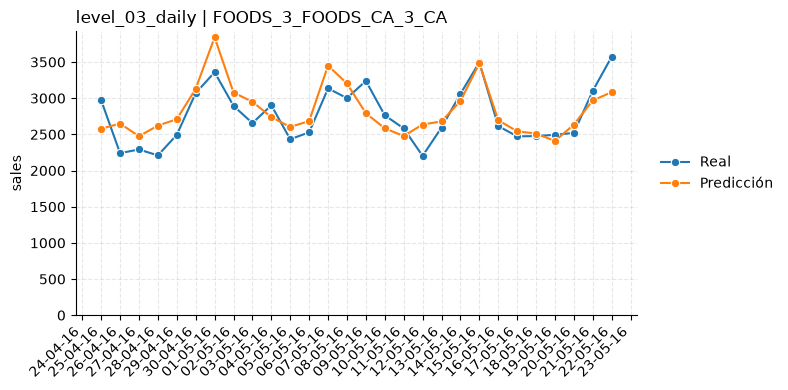

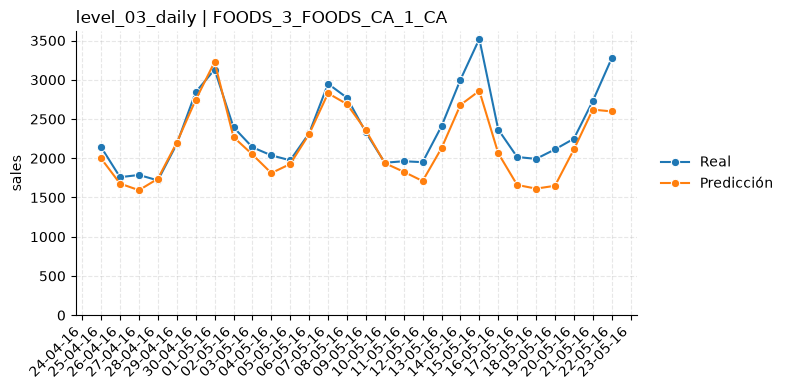

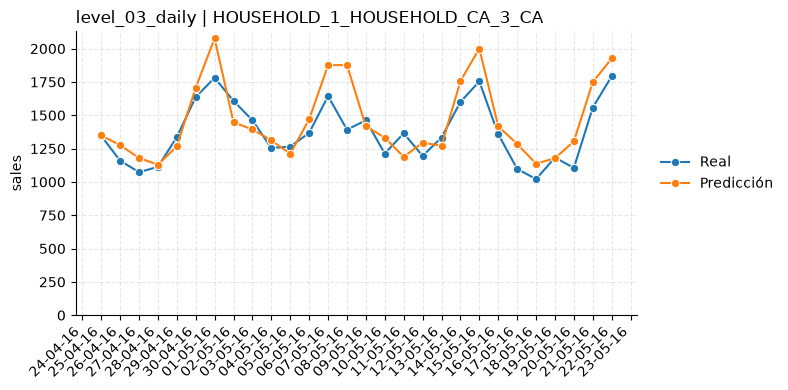

In [76]:
for i in df_metrics.sort_values('gross_sales_pct', ascending=False).head(3).index:
    plot_forecast(df_pred, level_label, 'sales', series_id=i)

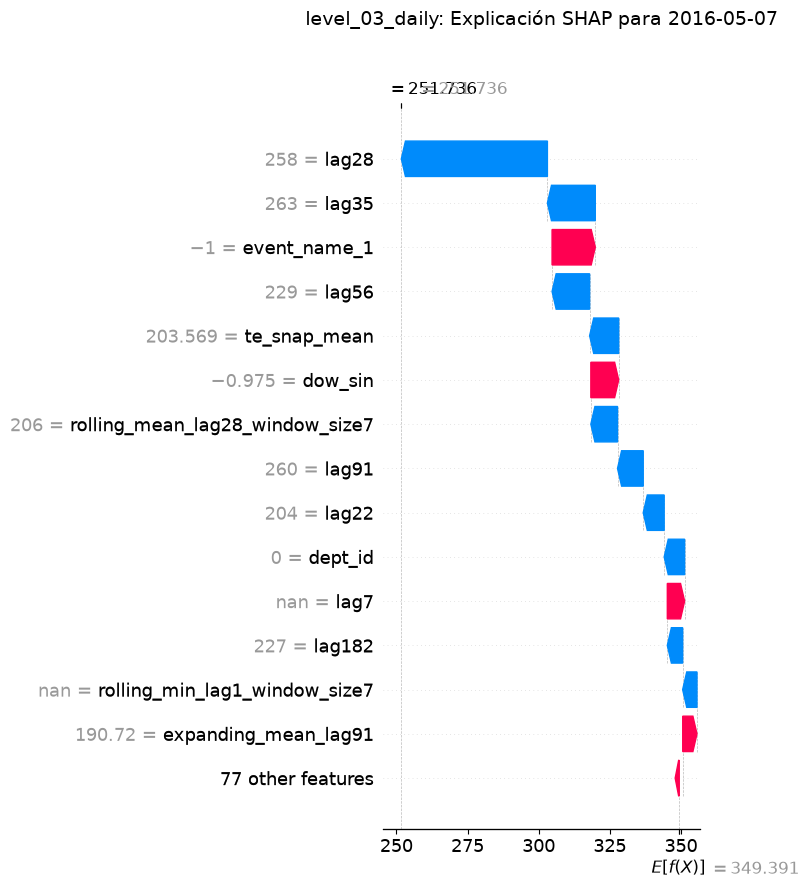

In [77]:
fecha = "2016-05-07"

test_meta = artifact["test"]
row_idx = test_meta.index[test_meta["date"] == pd.Timestamp(fecha)]

if row_idx.empty:
    raise ValueError(f"No hay datos de test para la fecha {fecha}")
if row_idx[0] not in X_shap.index:
    raise ValueError(f"La fecha {fecha} no fue muestreada en X_shap")

idx = X_shap.index.get_loc(row_idx[0])

base_value = np.ravel(explainer.expected_value)[0]

plt.figure(figsize=(8, 5))

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[idx],
        base_values=base_value,
        data=X_shap.iloc[idx],
        feature_names=X_shap.columns.tolist()
    ),
    max_display=15,
    show=False
)

fig = plt.gcf()

# recorre TODOS los ejes de la figura, no solo el actual
for ax in fig.axes:
    for text in ax.texts:
        text.set_visible(False)
        
plt.title(f"{level_label}: Explicación SHAP para {fecha}", fontsize=14, pad=60)
plt.tight_layout()
plt.show()

# Sandox

In [78]:
SERIES = 'HOUSEHOLD_CA_1_CA'
df_sample = df_pred.query(f'series_id == "{SERIES}"').copy()

#display(df_sample)

top_best_dates = df_pred.query(f'series_id == "{SERIES}"').nsmallest(2, 'wape')['date']
top_error_dates = df_pred.query(f'series_id == "{SERIES}"').nlargest(2, 'wape')['date']

#plot_forecast(df_pred, 'sales', series_id=SERIES)
#plot_forecast(df_pred, 'gross_sales', series_id=SERIES)
#plot_forecast(df_pred, 'wape', series_id=SERIES)
#plot_forecast(df_pred, 'bias', series_id=SERIES)

In [79]:
SERIES = "FOODS_2_FOODS"

for i in top_error_dates:
    print("#"*50,f"Date: {i}", "#"*50)
    analizar_prediccion(test_df=artifact['test'], X_test=X_test, df_pred=df_pred, target_col=artifact['target'], series_id=SERIES, explainer=explainer, date=i)

In [80]:
for i in top_best_dates:
    print("#"*50,f"Date: {i}", "#"*50)
    analizar_prediccion(test_df=artifact['test'], X_test=X_test, df_pred=df_pred, target_col=artifact['target'], series_id=SERIES, explainer=explainer, date=i)